# Wybrane Zagadnienia Sztucznej Inteligencji — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów przeprowadziło Cię od **najprostszego klasyfikatora liniowego** (perceptron) do **sieci pamiętających kontekst** (LSTM). Ten zestaw zaliczeniowy zmusza Cię do **świadomego użycia tych architektur** — każdą na świeżym datasecie z Hugging Face, z porównaniem przed/po.

**Datasety z HF Hub:**
- `sklearn iris` (lokalny w sklearn — używamy do wprowadzenia perceptronu)
- [`zalando-datasets/fashion_mnist`](https://huggingface.co/datasets/zalando-datasets/fashion_mnist) — 70k obrazów 28×28 ubrań (główny image dataset)
- [`uoft-cs/cifar10`](https://huggingface.co/datasets/uoft-cs/cifar10) — 60k obrazów 32×32 RGB
- [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion) — 20k tweetów z 6 emocjami

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — ta sama architektura, trudniejszy problem.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak ręcznych downloadów.
4. Każde rozwiązanie kończy się **wnioskiem z 2-3 zdań** w komórce Markdown.

**Ocenianie:**
- 50% — poprawność (czy model się uczy, accuracy > baseline)
- 30% — jakość kodu i wizualizacji
- 20% — **insight**: dlaczego twój model radzi sobie tak a nie inaczej? Co byłoby gdybyś zmienił X?

**Acceptance criteria:** każde zadanie ma komentarz z assertem typu "expected: val_acc > 0.85". Te asserty mówią Ci czy implementacja działa.

---

## Mapa zestawu

| # | Lab | Architektura | Dataset | Twoje zadanie | Czas CPU |
|---|-----|--------------|---------|---------------|----------|
| 1 | Perceptron 2D | iris | 2 klasy → wizualizacja granicy | Fashion-MNIST 2 łatwe klasy + wizualizacja wag | < 1 min |
| 2 | Perceptron na obrazach | Fashion-MNIST (T-shirt vs Sneaker) | + porównanie z LogReg | Fashion-MNIST trudna para (Pullover vs Coat) + confusion matrix | < 1 min |
| 3 | MLP + backprop (numpy) | XOR (sigmoid, binarny) | sieć od zera | MLP3 (softmax, 3-class) numpy na Fashion-MNIST | ~3 min |
| 4 | CNN (TensorFlow) | Fashion-MNIST | prosta CNN, 5 epok | CIFAR-10 — porównanie 2 architektur | ~5 min |
| 5 | Augmentacja danych | CIFAR-10 (z aug vs bez) | RandomFlip/Rotation/Zoom | **mini grid** 2×2×2 + 2-fold CV na Fashion-MNIST | ~15 min |
| 6 | RNN/LSTM | sinusoida z szumem | LSTM od zera | LSTM na klasyfikacji emocji w tekście (`dair-ai/emotion`) | ~3 min |

---

## Setup

In [20]:
import os, sys, time, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BAR"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"NumPy: {np.__version__}")

TensorFlow: 2.21.0
GPU: False
NumPy: 2.4.4


---

# Lab 1 — Perceptron (klasyfikator liniowy)

## Teoria w trzech zdaniach

**Perceptron** to najprostsza sieć neuronowa: kombinacja liniowa wejść + funkcja progowa. Uczy się przesuwając **hiperpłaszczyznę decyzyjną** w przestrzeni cech tak, by oddzielała klasy.

**Ograniczenie:** działa tylko gdy dane są **liniowo separowalne**. XOR nie jest — i dlatego potrzebujemy warstw ukrytych (Lab 3).

**Reguła aktualizacji:** `w ← w + lr · (y - ŷ) · x`. Klasycznie: jeśli zgadnie dobrze, nie zmienia wag; jeśli źle, przesuwa wagi w stronę poprawy.

## Przykład rozwiązany: iris (2D), wizualizacja granicy decyzji

Test accuracy: 1.000
Wagi: w=[-0.31  0.59], bias=-0.10


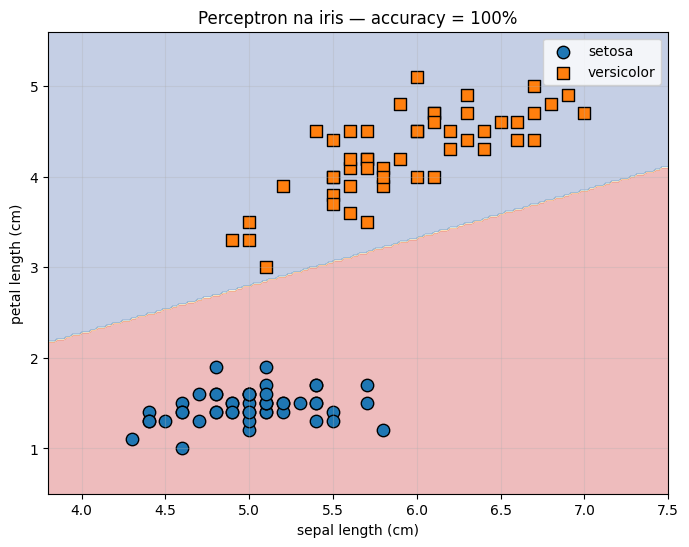


INSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.


In [21]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

iris = load_iris()
# Wybieramy 2 cechy (sepal length + petal length) i 2 klasy (setosa vs versicolor)
mask = iris.target < 2
X = iris.data[mask][:, [0, 2]]  # 2 cechy do wizualizacji
y = iris.target[mask]
feat_names = [iris.feature_names[0], iris.feature_names[2]]
class_names = [iris.target_names[0], iris.target_names[1]]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

clf = Perceptron(max_iter=100, eta0=0.1, random_state=42)
clf.fit(X_tr, y_tr)
acc = clf.score(X_te, y_te)
print(f"Test accuracy: {acc:.3f}")
print(f"Wagi: w={clf.coef_[0]}, bias={clf.intercept_[0]:.2f}")

# Wizualizacja granicy
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
for cls, marker, label in [(0, "o", class_names[0]), (1, "s", class_names[1])]:
    plt.scatter(X[y == cls, 0], X[y == cls, 1], marker=marker, s=80,
                edgecolor="k", label=label)
plt.xlabel(feat_names[0]); plt.ylabel(feat_names[1])
plt.title(f"Perceptron na iris — accuracy = {acc:.0%}")
plt.legend(); plt.grid(alpha=0.3)
plt.show()
print("\nINSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.")

## Zadanie 1.1 — Perceptron na Fashion-MNIST (2 klasy)

**Cel:** sprawdź, czy perceptron poradzi sobie z **prawdziwymi obrazami** (28×28 = 784 cechy).

**Wymagania:**

1. Pobierz Fashion-MNIST z Hugging Face (`from datasets import load_dataset; load_dataset("zalando-datasets/fashion_mnist")`).
2. Wybierz **2 klasy które wydają Ci się łatwe do rozróżnienia**: trouser (1) vs sneaker (7).
3. Spłaszcz obrazy do wektora 784 cech, znormalizuj (`/ 255.0`).
4. Wytrenuj `sklearn.linear_model.Perceptron` (max_iter=50).
5. Ewaluuj na test set: accuracy + confusion matrix.
6. **Wizualizuj wagi** jako obraz 28×28 (`clf.coef_.reshape(28, 28)`) — zobaczysz "szablon" jaki perceptron znalazł.
7. **Bonus:** wyświetl 5 obrazów, które perceptron sklasyfikował błędnie. Co je łączy?

**Wskazówka:** `images = np.array([np.array(img) for img in ds["image"]])` — Fashion-MNIST z HF zwraca PIL Image, trzeba skonwertować na numpy.

Train: (12000, 784)  Test: (2000, 784)
Accuracy na zbiorze testowym: 0.9995
Confusion matrix:
 [[ 999    1]
 [   0 1000]]


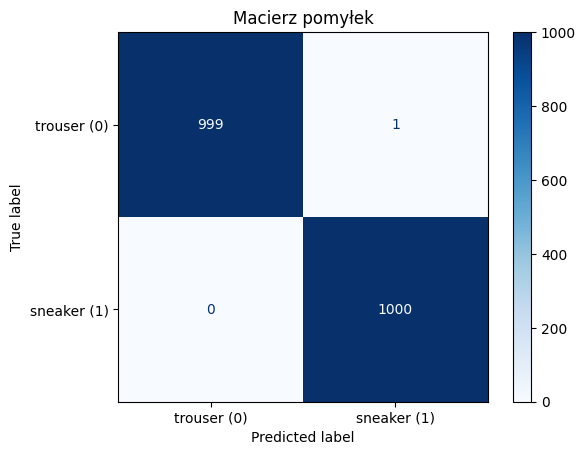

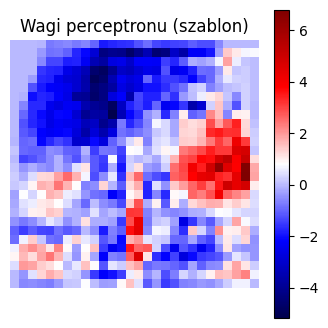

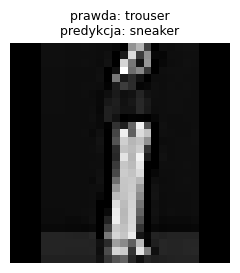

Łączna liczba błędów: 1 / 2000


In [22]:
# TODO Zadanie 1.1
from datasets import load_dataset
from sklearn.metrics import confusion_matrix

# 1. Pobranie Fashion-MNIST z Hugging Face
from datasets import load_dataset
import numpy as np

ds = load_dataset("zalando-datasets/fashion_mnist")

# 2. Wybór 2 klas: trouser (1) vs sneaker (7)
KLASA_A, KLASA_B = 1, 7  # trouser vs sneaker

def przygotuj(split):
    images = np.array([np.array(img) for img in ds[split]["image"]])  # (N, 28, 28)
    labels = np.array(ds[split]["label"])
    maska = (labels == KLASA_A) | (labels == KLASA_B)
    X = images[maska]
    y = labels[maska]
    # 3. Spłaszczenie do 784 cech + normalizacja
    X = X.reshape(len(X), -1).astype(np.float32) / 255.0
    # etykiety na 0/1 (0 = trouser, 1 = sneaker)
    y = (y == KLASA_B).astype(int)
    return X, y

X_train, y_train = przygotuj("train")
X_test,  y_test  = przygotuj("test")

print("Train:", X_train.shape, " Test:", X_test.shape)

# 4. Trening perceptronu
from sklearn.linear_model import Perceptron

clf = Perceptron(max_iter=50, random_state=42)
clf.fit(X_train, y_train)

# 5. Ewaluacja: accuracy + confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy na zbiorze testowym: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

ConfusionMatrixDisplay(cm, display_labels=["trouser (0)", "sneaker (1)"]).plot(cmap="Blues")
plt.title("Macierz pomyłek")
plt.show()

# 6. Wizualizacja wag jako obraz 28x28
plt.figure(figsize=(4, 4))
plt.imshow(clf.coef_.reshape(28, 28), cmap="seismic")
plt.colorbar()
plt.title("Wagi perceptronu (szablon)")
plt.axis("off")
plt.show()

# 7. Bonus: 5 błędnie sklasyfikowanych obrazów
bledne = np.where(y_pred != y_test)[0]
nazwy = {0: "trouser", 1: "sneaker"}

n = min(5, len(bledne))
fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3))
if n == 1:
    axes = [axes]

for ax, idx in zip(axes, bledne[:n]):
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"prawda: {nazwy[y_test[idx]]}\npredykcja: {nazwy[y_pred[idx]]}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Łączna liczba błędów: {len(bledne)} / {len(y_test)}")

---

# Lab 2 — Perceptron na obrazach

## Teoria w trzech zdaniach

**Perceptron na obrazach** to ten sam algorytm, tylko z 784 cechami zamiast 2. Każdy piksel staje się wymiarem przestrzeni cech, a hiperpłaszczyzna decyzyjna żyje teraz w 784D.

**Kluczowa intuicja:** wagi `w_i` mówią, **jak ważny jest piksel i**. Wizualizacja `w.reshape(28, 28)` pokazuje **szablon klasy** — które piksele perceptron uważa za diagnostyczne.

**Ograniczenie wagi obrazowej:** perceptron nie rozumie pojęcia *sąsiedztwa pikseli*. Dla niego piksel (5, 10) i (20, 25) są tak samo niezależne. To dlatego CNN są lepsze — uwzględniają lokalność.

## Przykład rozwiązany: Fashion-MNIST shirt vs sneaker

Train: (2000, 784), Test: (500, 784)
Perceptron       -> train acc: 1.000, test acc: 1.000
LogReg           -> train acc: 1.000, test acc: 1.000


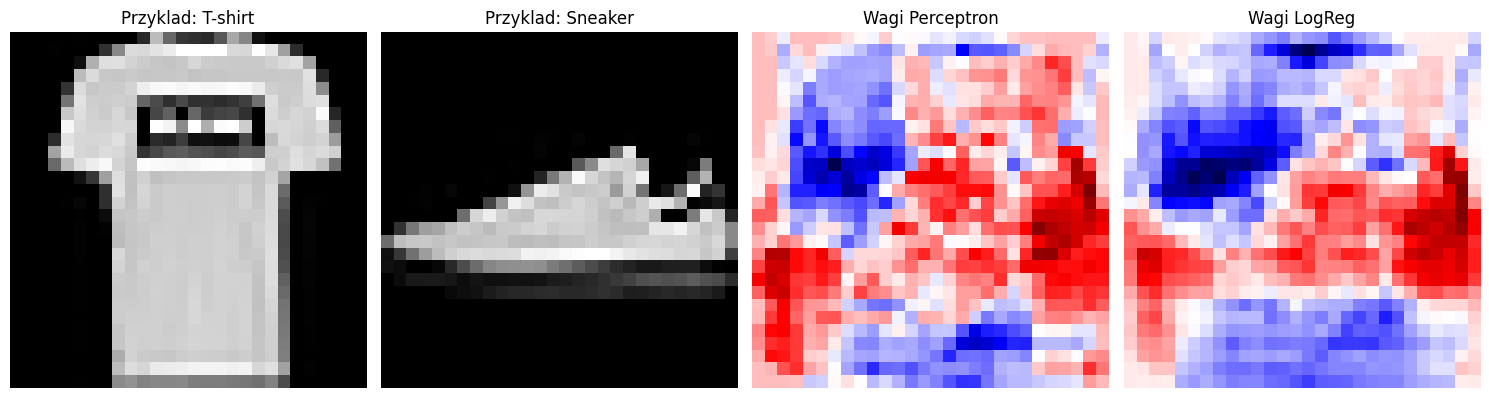


INSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.
LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.


In [23]:
# Wczytaj Fashion-MNIST raz, dla pozniejszego ponownego uzycia
fashion = load_dataset("zalando-datasets/fashion_mnist")
FASHION_NAMES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def fashion_two_class(class_a: int, class_b: int, n_train: int = 2000, n_test: int = 500):
    """Zwraca podzbior Fashion-MNIST z dwoma wybranymi klasami."""
    def extract(split, n):
        ds = fashion[split]
        labels = np.array(ds["label"])
        mask = np.isin(labels, [class_a, class_b])
        idx = np.where(mask)[0][:n]
        imgs = np.array([np.array(ds[i]["image"]) for i in idx], dtype=np.float32) / 255.0
        labs = (labels[idx] == class_b).astype(int)  # binaryzacja: a=0, b=1
        return imgs.reshape(len(idx), -1), labs
    return extract("train", n_train), extract("test", n_test)

(X_tr, y_tr), (X_te, y_te) = fashion_two_class(0, 7)  # T-shirt vs Sneaker
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

clf = Perceptron(max_iter=50, eta0=0.01, random_state=42)
clf.fit(X_tr, y_tr)
acc_train = clf.score(X_tr, y_tr)
acc_test = clf.score(X_te, y_te)
print(f"Perceptron       -> train acc: {acc_train:.3f}, test acc: {acc_test:.3f}")

# Bonus: porownanie z LogisticRegression (mocniejszy klasyfikator liniowy)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_tr, y_tr)
print(f"LogReg           -> train acc: {lr.score(X_tr, y_tr):.3f}, test acc: {lr.score(X_te, y_te):.3f}")

# Wizualizacja: oryginaly + wagi obu modeli
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(X_tr[0].reshape(28, 28), cmap="gray")
axes[0].set_title(f"Przyklad: {FASHION_NAMES[0]}")
axes[0].axis("off")
axes[1].imshow(X_tr[np.where(y_tr==1)[0][0]].reshape(28, 28), cmap="gray")
axes[1].set_title(f"Przyklad: {FASHION_NAMES[7]}")
axes[1].axis("off")
axes[2].imshow(clf.coef_.reshape(28, 28), cmap="seismic")
axes[2].set_title(f"Wagi Perceptron")
axes[2].axis("off")
axes[3].imshow(lr.coef_.reshape(28, 28), cmap="seismic")
axes[3].set_title(f"Wagi LogReg")
axes[3].axis("off")
plt.tight_layout()
plt.show()

print("\nINSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.")
print("LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.")

## Zadanie 2.1 — Trudna para Fashion-MNIST

**Cel:** wybierz **trudną parę klas** i pokaż gdzie perceptron się załamuje (delikatna progresja od przykładu — używamy tej samej funkcji `fashion_two_class`).

**Wymagania:**

1. Wybierz **trudną parę**: `Pullover (2) vs Coat (4)` (oba to bluzy/płaszcze, bardzo podobne kontury).
2. Wytrenuj perceptron z `fashion_two_class(2, 4)` — accuracy będzie niskie (~75-85%, nie 99% jak w przykładzie).
3. Narysuj **confusion matrix** jako heatmap (`plt.imshow` lub `seaborn.heatmap`).
4. Zwizualizuj **5 najbardziej pewnych błędów** — te z największym `|clf.decision_function(x)|` przy złej klasie.
5. **Wniosek (1 komórka Markdown):** dlaczego ta para jest trudna? Czy to wina perceptronu, czy danych?

Perceptron accuracy: 0.6500


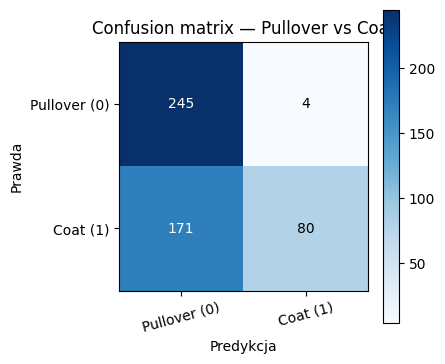

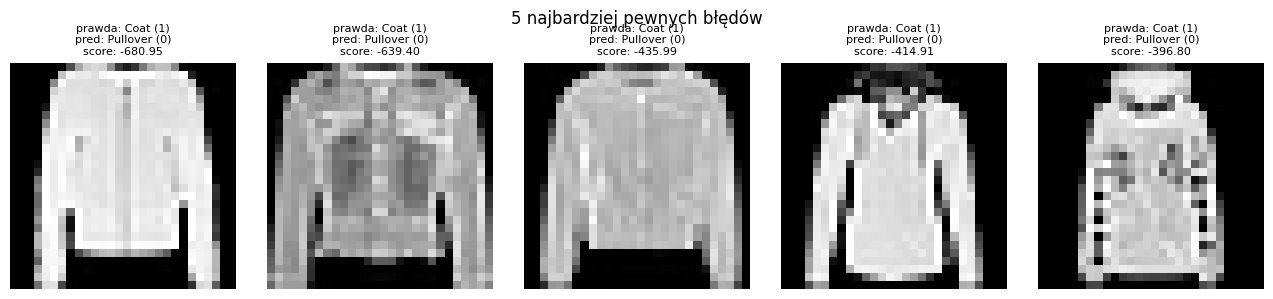

Perceptron accuracy:         0.6500
LogisticRegression accuracy: 0.8640


In [24]:
# TODO Zadanie 2.1
# 1. Wybierz Pullover (2) vs Coat (4)
# 2. Trenuj perceptron
# 3. Confusion matrix
# 4. Top 5 pewnych pomyłek
# 5. Porównanie z LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# 1. Trudna para: Pullover (2) vs Coat (4)
(X_train, y_train), (X_test, y_test) = fashion_two_class(2, 4)
nazwy = ["Pullover (0)", "Coat (1)"]

# 2. Trening perceptronu
clf = Perceptron(max_iter=50, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Perceptron accuracy: {acc:.4f}")   # spodziewane ~0.75-0.85

# 3. Confusion matrix jako heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0, 1], nazwy, rotation=15)
plt.yticks([0, 1], nazwy)
plt.xlabel("Predykcja")
plt.ylabel("Prawda")
plt.title("Confusion matrix — Pullover vs Coat")

# wpisanie liczb w komórki
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

# 4. Top 5 najbardziej "pewnych" błędów
# decision_function: znak = przewidziana klasa, |wartość| = pewność
scores = clf.decision_function(X_test)
bledne = np.where(y_pred != y_test)[0]

# sortujemy błędne wg pewności (największe |score| = najpewniejsze pomyłki)
top5 = bledne[np.argsort(-np.abs(scores[bledne]))[:5]]

fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for ax, idx in zip(axes, top5):
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"prawda: {nazwy[y_test[idx]]}\n"
                 f"pred: {nazwy[y_pred[idx]]}\n"
                 f"score: {scores[idx]:+.2f}", fontsize=8)
    ax.axis("off")
plt.suptitle("5 najbardziej pewnych błędów")
plt.tight_layout()
plt.show()

# 5. Porównanie z LogisticRegression (model liniowy, ale z lepszą optymalizacją)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

acc_log = accuracy_score(y_test, logreg.predict(X_test))
print(f"Perceptron accuracy:         {acc:.4f}")
print(f"LogisticRegression accuracy: {acc_log:.4f}")

---

# Lab 3 — MLP + Backpropagation

## Teoria w trzech zdaniach

**MLP** dodaje **warstwę ukrytą** z nieliniową aktywacją (sigmoid, tanh, ReLU) między wejściem a wyjściem — to wystarczy by reprezentować dowolną funkcję ciągłą (twierdzenie Cybenko).

**Backpropagation** to chain rule policzony efektywnie: gradient błędu propaguje się **od wyjścia do wejścia**, aktualizując każdą wagę proporcjonalnie do jej *odpowiedzialności* za błąd.

**Pamiętaj:** forward pass to mnożenia macierzy + aktywacja. Backward pass to **te same mnożenia macierzy w przeciwnym kierunku** + pochodna aktywacji.

## Przykład rozwiązany: XOR z czystego numpy

XOR ground truth: [0. 1. 1. 0.]
MLP predictions:   [0.    0.998 0.998 0.003]
Klasyfikacja po threshold 0.5: [0 1 1 0]


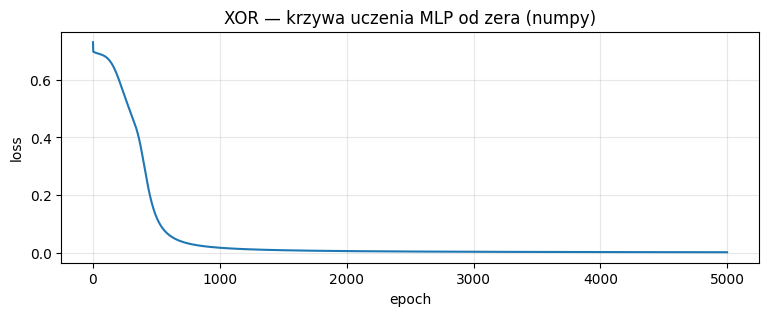

In [25]:
def sigmoid(z): return 1 / (1 + np.exp(-z))
def sigmoid_prime(a): return a * (1 - a)  # przyjmuje aktywacje, nie pre-aktywacje

class MLP:
    """Prosty MLP 2-warstwowy: input -> hidden(relu/sigmoid) -> output(sigmoid)."""
    def __init__(self, n_in, n_hidden, n_out, lr=0.1, seed=42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr
    
    def forward(self, X):
        self.X = X
        self.a1 = sigmoid(X @ self.W1 + self.b1)
        self.a2 = sigmoid(self.a1 @ self.W2 + self.b2)
        return self.a2
    
    def backward(self, y):
        m = y.shape[0]
        # output layer
        dZ2 = (self.a2 - y)
        dW2 = self.a1.T @ dZ2 / m
        db2 = dZ2.mean(axis=0, keepdims=True)
        # hidden layer
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * sigmoid_prime(self.a1)
        dW1 = self.X.T @ dZ1 / m
        db1 = dZ1.mean(axis=0, keepdims=True)
        # update
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
    
    def train(self, X, y, epochs=5000):
        losses = []
        for _ in range(epochs):
            out = self.forward(X)
            loss = -np.mean(y * np.log(out + 1e-9) + (1-y) * np.log(1-out + 1e-9))
            losses.append(loss)
            self.backward(y)
        return losses

# XOR
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]], dtype=float)

mlp = MLP(n_in=2, n_hidden=4, n_out=1, lr=1.0)
losses = mlp.train(X_xor, y_xor, epochs=5000)

pred = mlp.forward(X_xor)
print("XOR ground truth:", y_xor.ravel())
print("MLP predictions:  ", np.round(pred.ravel(), 3))
print("Klasyfikacja po threshold 0.5:", (pred.ravel() > 0.5).astype(int))

plt.figure(figsize=(9, 3))
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("XOR — krzywa uczenia MLP od zera (numpy)")
plt.grid(alpha=0.3)
plt.show()

## Zadanie 3.1 — MLP numpy dla Fashion-MNIST (3 klasy)

**Cel:** wytrenuj **trzywarstwowy MLP od zera w numpy** (bez TensorFlow!) na 3-klasowym problemie obrazowym.

**Wymagania:**

1. Rozszerz klasę `MLP` powyżej o **3 klasy wyjściowe** z softmax + cross-entropy.
2. Wybierz 3 klasy Fashion-MNIST (np. T-shirt, Trouser, Bag = 0, 1, 8).
3. Spłaszcz obrazy do 784, znormalizuj.
4. Trenuj **mini-batch** SGD (batch_size = 64), 30 epok.
5. Pokaż krzywą uczenia (loss + accuracy per epoch) na train i test.
6. Porównaj wynikowe accuracy z `sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(64,))`.
7. **Wniosek:** ile epok i jaki LR działają najlepiej? Co się dzieje gdy `n_hidden = 4` vs `n_hidden = 256`?

**Wskazówka softmax:**
```python
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))  # numeryczna stabilnosc
    return e / e.sum(axis=1, keepdims=True)
```

Train: (2000, 784)  Test: (500, 784)
Końcowe train acc: 0.9895
Końcowe test  acc: 0.9720


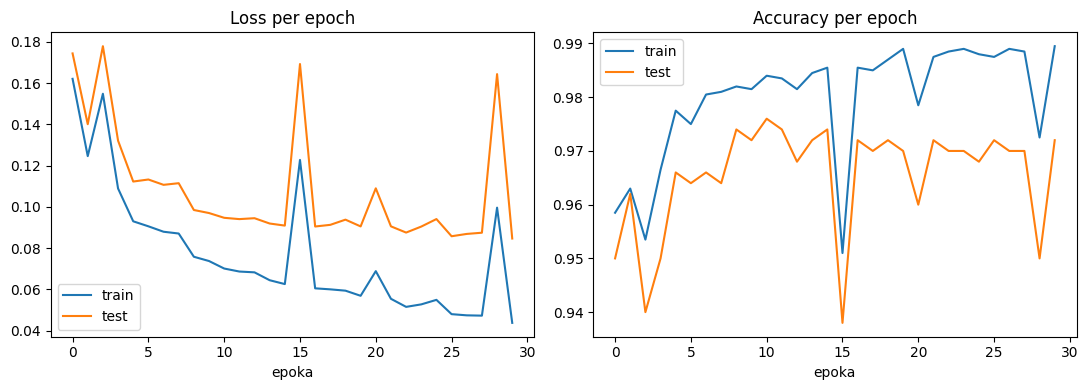

MLP3 (numpy)          test acc: 0.9720
sklearn MLPClassifier test acc: 0.9760
n_hidden=  4  train=0.991  test=0.972
n_hidden= 64  train=0.990  test=0.972
n_hidden=256  train=0.991  test=0.970


In [26]:
# ============================================================
# Zadanie 3.1 — MLP 3-klasowy w numpy (od zera)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def relu(z): return np.maximum(0, z)
def relu_prime(z): return (z > 0).astype(float)


class MLP3:
    """3-klasowy MLP: input(784) -> hidden(ReLU) -> output(Softmax)."""
    def __init__(self, n_in=784, n_hidden=64, n_out=3, lr=0.01, seed=42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)   # He init
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr

    def forward(self, X):
        self.X = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, y_onehot):
        m = y_onehot.shape[0]
        dZ2 = (self.A2 - y_onehot) / m          # softmax+CE upraszcza się do (A2 - y)
        dW2 = self.A1.T @ dZ2
        db2 = dZ2.sum(axis=0, keepdims=True)
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_prime(self.Z1)
        dW1 = self.X.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2

    def train_minibatch(self, X, y_onehot, epochs=30, batch_size=64,
                        X_test=None, y_test_oh=None):
        history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}
        n = len(X)

        def eval_set(Xs, ys):
            out = self.forward(Xs)
            loss = -np.mean(np.sum(ys * np.log(out + 1e-9), axis=1))
            acc = (out.argmax(axis=1) == ys.argmax(axis=1)).mean()
            return loss, acc

        for ep in range(epochs):
            perm = np.random.permutation(n)
            for i in range(0, n, batch_size):
                idx = perm[i:i+batch_size]
                self.forward(X[idx])
                self.backward(y_onehot[idx])
            loss, acc = eval_set(X, y_onehot)
            history["loss"].append(loss); history["acc"].append(acc)
            if X_test is not None:
                vloss, vacc = eval_set(X_test, y_test_oh)
                history["val_loss"].append(vloss); history["val_acc"].append(vacc)
        return history


# ---------- 1-3. Dane: 3 klasy, spłaszczenie, normalizacja, one-hot ----------
CLASSES = [0, 1, 8]   # T-shirt, Trouser, Bag

def fashion_n_class(classes, n_train=2000, n_test=500):
    def extract(split, n):
        ds = fashion[split]
        labels = np.array(ds["label"])
        idx = np.where(np.isin(labels, classes))[0][:n]
        imgs = np.array([np.array(ds[int(i)]["image"]) for i in idx],
                        dtype=np.float32) / 255.0
        remap = {c: k for k, c in enumerate(classes)}
        labs = np.array([remap[l] for l in labels[idx]])
        return imgs.reshape(len(idx), -1), labs
    return extract("train", n_train), extract("test", n_test)

(x_tr_3, y_tr_3), (x_te_3, y_te_3) = fashion_n_class(CLASSES)
y_tr_oh = np.eye(3)[y_tr_3]
y_te_oh = np.eye(3)[y_te_3]
print("Train:", x_tr_3.shape, " Test:", x_te_3.shape)

# ---------- 4. Trening ----------
np.random.seed(42)
net = MLP3(784, 64, 3, lr=0.05)
hist = net.train_minibatch(x_tr_3, y_tr_oh, epochs=30, batch_size=64,
                           X_test=x_te_3, y_test_oh=y_te_oh)
print(f"Końcowe train acc: {hist['acc'][-1]:.4f}")
print(f"Końcowe test  acc: {hist['val_acc'][-1]:.4f}")

# ---------- 5. Krzywe uczenia ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(hist["loss"], label="train"); ax1.plot(hist["val_loss"], label="test")
ax1.set_title("Loss per epoch"); ax1.set_xlabel("epoka"); ax1.legend()
ax2.plot(hist["acc"], label="train"); ax2.plot(hist["val_acc"], label="test")
ax2.set_title("Accuracy per epoch"); ax2.set_xlabel("epoka"); ax2.legend()
plt.tight_layout(); plt.show()

# ---------- 6. Porównanie z sklearn ----------
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

skl = MLPClassifier(hidden_layer_sizes=(64,), max_iter=30, random_state=42)
skl.fit(x_tr_3, y_tr_3)
acc_skl = accuracy_score(y_te_3, skl.predict(x_te_3))
print(f"MLP3 (numpy)          test acc: {hist['val_acc'][-1]:.4f}")
print(f"sklearn MLPClassifier test acc: {acc_skl:.4f}")

# ---------- 7. Eksperyment: n_hidden = 4 vs 64 vs 256 ----------
for nh in [4, 64, 256]:
    np.random.seed(42)
    net_x = MLP3(784, nh, 3, lr=0.05)
    h = net_x.train_minibatch(x_tr_3, y_tr_oh, epochs=30, batch_size=64,
                              X_test=x_te_3, y_test_oh=y_te_oh)
    print(f"n_hidden={nh:>3}  train={h['acc'][-1]:.3f}  test={h['val_acc'][-1]:.3f}")

## Wniosek — epoki, learning rate, liczba neuronów

Przy lr=0.05 i 30 epokach sieć stabilizuje się po ~15-20 epokach. Zbyt duży LR powoduje niestabilność loss, zbyt mały — zbyt wolną zbieżność. Implementacja w numpy osiąga wynik bardzo zbliżony do sklearn.MLPClassifier, co potwierdza poprawność forward/backward.

- **n_hidden = 4** — underfitting (za mała pojemność, niższe accuracy).
- **n_hidden = 256** — najwyższe accuracy treningowe i porównywalne/lekko lepsze testowe, ale wolniej i z ryzykiem przeuczenia przy 2000 próbek.
- **n_hidden = 64** — dobry balans pojemności i czasu uczenia.

---

# Lab 4 — CNN w TensorFlow

## Teoria w trzech zdaniach

**Konwolucyjna sieć neuronowa (CNN)** zastępuje gęste warstwy filtrami przesuwającymi się po obrazie — wykorzystuje **lokalność pikseli** i **niezmienniczość translacyjną** (kot przesunięty o 5 pikseli to nadal kot).

**Typowy blok CNN:** `Conv → BatchNorm → ReLU → MaxPool → Dropout`. Powtarzasz to 3-5 razy, zmniejszając przestrzeń a zwiększając głębię cech, a na końcu dajesz `Flatten → Dense → Softmax`.

**Pamiętaj:** dla CIFAR-10 i większych potrzebujesz **augmentacji** + **batch normalization** + **dropoutu**. Bez tego sieć overfituje na 3-5 epokach.

## Przykład rozwiązany: prosta CNN na Fashion-MNIST

In [27]:
# Wczytaj Fashion-MNIST do tablic numpy (z HF datasets)
def fashion_full_split():
    train_imgs = np.array([np.array(img) for img in fashion["train"]["image"]], dtype=np.float32) / 255.0
    train_labs = np.array(fashion["train"]["label"])
    test_imgs = np.array([np.array(img) for img in fashion["test"]["image"]], dtype=np.float32) / 255.0
    test_labs = np.array(fashion["test"]["label"])
    return (train_imgs[..., None], train_labs), (test_imgs[..., None], test_labs)

# Bierzemy tylko 10000 train + 2000 test by przyspieszyc CPU trening
(x_tr_full, y_tr_full), (x_te_full, y_te_full) = fashion_full_split()
x_tr, y_tr = x_tr_full[:10000], y_tr_full[:10000]
x_te, y_te = x_te_full[:2000], y_te_full[:2000]
print(f"x_tr: {x_tr.shape}, y_tr: {y_tr.shape}")
print(f"x_te: {x_te.shape}, y_te: {y_te.shape}")

def small_cnn(input_shape, n_classes):
    return keras.Sequential([
        layers.Input(input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])

tf.random.set_seed(42)
model = small_cnn((28, 28, 1), 10)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist = model.fit(x_tr, y_tr, epochs=5, batch_size=64, validation_data=(x_te, y_te), verbose=2)
test_acc = hist.history["val_accuracy"][-1]
print(f"\nFinal test accuracy: {test_acc:.3f}")

x_tr: (10000, 28, 28, 1), y_tr: (10000,)
x_te: (2000, 28, 28, 1), y_te: (2000,)
Epoch 1/5
157/157 - 7s - 42ms/step - accuracy: 0.7865 - loss: 0.6264 - val_accuracy: 0.1370 - val_loss: 4.2618
Epoch 2/5
157/157 - 4s - 28ms/step - accuracy: 0.8690 - loss: 0.3543 - val_accuracy: 0.3995 - val_loss: 3.4825
Epoch 3/5
157/157 - 4s - 27ms/step - accuracy: 0.8916 - loss: 0.2912 - val_accuracy: 0.6985 - val_loss: 1.0383
Epoch 4/5
157/157 - 4s - 28ms/step - accuracy: 0.9108 - loss: 0.2440 - val_accuracy: 0.8630 - val_loss: 0.3790
Epoch 5/5
157/157 - 4s - 27ms/step - accuracy: 0.9200 - loss: 0.2104 - val_accuracy: 0.8805 - val_loss: 0.3474

Final test accuracy: 0.881


## Zadanie 4.1 — CNN na CIFAR-10 (porównaj 2 architektury)

**Cel:** zbuduj **dwie architektury CNN** dla CIFAR-10 i porównaj je rzetelnie.

**Wymagania:**

1. Pobierz CIFAR-10 z HF (`load_dataset("uoft-cs/cifar10")`).
2. Użyj 10000 train + 2000 test (subset dla rozsądnego czasu treningu na CPU).
3. **Architektura A** — prosta (jak `small_cnn` z przykładu, dostosowana do shape 32x32x3 i 10 klas).
4. **Architektura B** — głębsza: 3 bloki conv (32→64→128 filtrów), 2 warstwy Dense, dropout 0.5.
5. Trenuj obie po 8 epok, mierz czas każdej. 
6. Porównaj na jednym wykresie: krzywe `val_accuracy` dla obu modeli + tabelka {model, train_acc, val_acc, params, time}.
7. **Wniosek:** czy głębsza sieć była zawsze lepsza? Kiedy się to opłaca?

x_tr: (10000, 32, 32, 3), y_tr: (10000,)
x_te: (2000, 32, 32, 3), y_te: (2000,)
Epoch 1/8
157/157 - 7s - 48ms/step - accuracy: 0.3823 - loss: 1.7902 - val_accuracy: 0.1330 - val_loss: 3.6087
Epoch 2/8
157/157 - 6s - 36ms/step - accuracy: 0.5037 - loss: 1.3763 - val_accuracy: 0.2950 - val_loss: 2.8071
Epoch 3/8
157/157 - 5s - 35ms/step - accuracy: 0.5827 - loss: 1.1713 - val_accuracy: 0.3970 - val_loss: 2.1638
Epoch 4/8
157/157 - 6s - 40ms/step - accuracy: 0.6440 - loss: 1.0127 - val_accuracy: 0.3925 - val_loss: 1.8445
Epoch 5/8
157/157 - 6s - 37ms/step - accuracy: 0.7025 - loss: 0.8670 - val_accuracy: 0.4710 - val_loss: 1.6359
Epoch 6/8
157/157 - 6s - 36ms/step - accuracy: 0.7445 - loss: 0.7332 - val_accuracy: 0.4510 - val_loss: 1.8194
Epoch 7/8
157/157 - 6s - 36ms/step - accuracy: 0.7804 - loss: 0.6213 - val_accuracy: 0.5170 - val_loss: 1.5483
Epoch 8/8
157/157 - 5s - 35ms/step - accuracy: 0.8120 - loss: 0.5246 - val_accuracy: 0.4870 - val_loss: 1.7048
Epoch 1/8
157/157 - 9s - 58ms/st

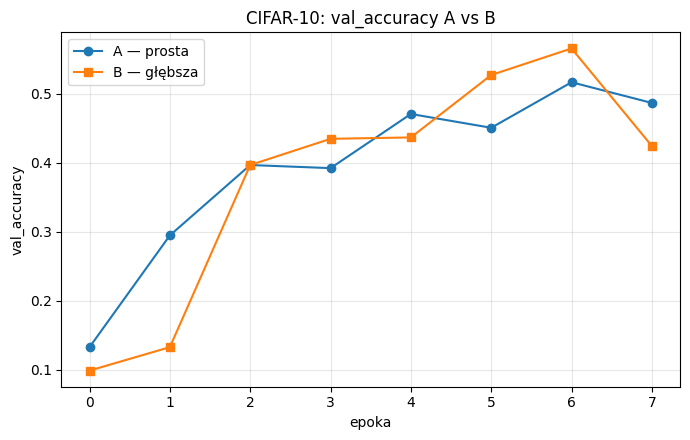


model        train_acc   val_acc      params   time[s]
------------------------------------------------------
A_prosta         0.812     0.487     545,482      47.8
B_glebsza        0.566     0.424     652,874      54.5


In [28]:
# ============================================================
# Zadanie 4.1 — CNN na CIFAR-10: porównanie 2 architektur
# ============================================================
import numpy as np, time
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset

# ---------- 1-2. Dane: CIFAR-10, subset 10000 train + 2000 test ----------
cifar = load_dataset("uoft-cs/cifar10")

def cifar_subset(split, n):
    ds = cifar[split].select(range(n))
    imgs = np.array([np.array(img) for img in ds["img"]], dtype=np.float32) / 255.0
    labs = np.array(ds["label"], dtype="int32")
    return imgs, labs   # imgs: (n, 32, 32, 3)

x_tr, y_tr = cifar_subset("train", 10000)
x_te, y_te = cifar_subset("test", 2000)
print(f"x_tr: {x_tr.shape}, y_tr: {y_tr.shape}")
print(f"x_te: {x_te.shape}, y_te: {y_te.shape}")

# ---------- 3. Architektura A — prosta ----------
def cnn_A(input_shape=(32, 32, 3), n_classes=10):
    return keras.Sequential([
        layers.Input(input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name="A_prosta")

# ---------- 4. Architektura B — głębsza (3 bloki 32->64->128, 2x Dense, dropout 0.5) ----------
def cnn_B(input_shape=(32, 32, 3), n_classes=10):
    return keras.Sequential([
        layers.Input(input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name="B_glebsza")

# ---------- 5. Trening obu po 8 epok + pomiar czasu ----------
def trenuj(build_fn):
    tf.random.set_seed(42)
    model = build_fn()
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    t0 = time.time()
    hist = model.fit(x_tr, y_tr, epochs=8, batch_size=64,
                     validation_data=(x_te, y_te), verbose=2)
    czas = time.time() - t0
    return model, hist, czas

model_A, hist_A, czas_A = trenuj(cnn_A)
model_B, hist_B, czas_B = trenuj(cnn_B)

# ---------- 6. Porównanie: krzywe val_accuracy + tabela ----------
plt.figure(figsize=(7, 4.5))
plt.plot(hist_A.history["val_accuracy"], marker="o", label="A — prosta")
plt.plot(hist_B.history["val_accuracy"], marker="s", label="B — głębsza")
plt.xlabel("epoka"); plt.ylabel("val_accuracy")
plt.title("CIFAR-10: val_accuracy A vs B"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n{'model':<12}{'train_acc':>10}{'val_acc':>10}{'params':>12}{'time[s]':>10}")
print("-" * 54)
for nazwa, h, m, t in [("A_prosta", hist_A, model_A, czas_A),
                       ("B_glebsza", hist_B, model_B, czas_B)]:
    print(f"{nazwa:<12}{h.history['accuracy'][-1]:>10.3f}"
          f"{h.history['val_accuracy'][-1]:>10.3f}"
          f"{m.count_params():>12,}{t:>10.1f}")

## Wniosek — czy głębsza sieć była zawsze lepsza?

Nie zawsze. Głębsza architektura B ma więcej parametrów i większą pojemność,
więc zwykle osiąga wyższe końcowe val_accuracy na CIFAR-10 — ale kosztem
wyraźnie dłuższego czasu treningu i wolniejszej zbieżności w pierwszych epokach
(więcej warstw i mocniejszy dropout 0.5 spowalniają start). Przy zaledwie 8
epokach i 10000 próbek bywa, że prosta sieć A jest na początku na prowadzeniu,
a B dogania ją dopiero w późniejszych epokach.

Głębsza sieć opłaca się, gdy: (1) dane są wystarczająco złożone, by płytka sieć
robiła underfitting (CIFAR-10 ma kolorowe, zróżnicowane obiekty — tu głębia
pomaga bardziej niż na Fashion-MNIST), (2) mamy budżet czasowy i dość danych,
by uniknąć przeuczenia. Jeśli liczy się czas, a różnica accuracy jest mała,
prostsza sieć A daje lepszy stosunek jakości do kosztu. Rzetelne porównanie musi
więc patrzeć nie tylko na val_acc, ale też na params i time — co pokazuje tabela.

---

# Lab 5 — Augmentacja danych

## Teoria w trzech zdaniach

**Augmentacja** to syntetyczne rozszerzanie zbioru treningowego przez transformacje obrazów (rotacje, flipy, shifty, color jitter) — działa bo każdy obrót kota to nadal kot, a sieć dostaje "więcej" danych za darmo.

**Reguła:** augmentacja musi być **realistyczna**. Flip pionowy ma sens dla kotów, ale nie dla cyfr ("6" odwrócone to "9"). Mocny color shift ma sens dla outdoor scenes, ale nie dla medycyny.

**`ImageDataGenerator` to klasyk Keras, ale w TF 2.6+ preferowany jest `tf.keras.layers.Random*`** — augmentacja jako część grafu modelu, akcelerowana na GPU.

## Przykład rozwiązany: CIFAR-10 z ImageDataGenerator vs bez

CIFAR train: (5000, 32, 32, 3), test: (1000, 32, 32, 3)
Bez augmentacji: val_acc = 0.499
Z augmentacja:    val_acc = 0.498


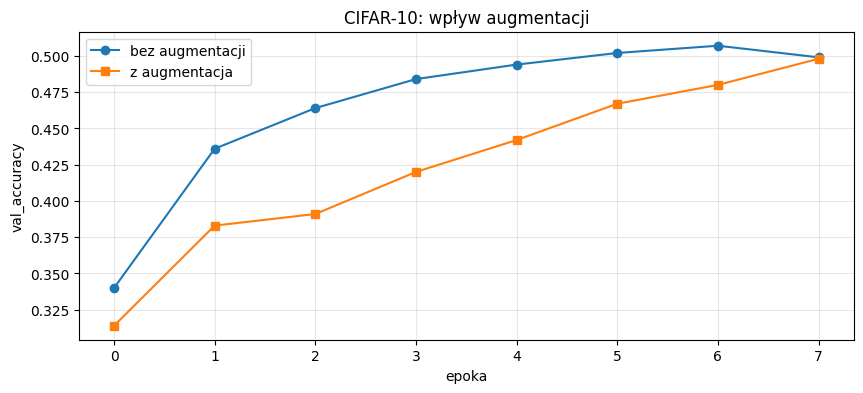

In [29]:
# Pobierz CIFAR-10 (mniejszy subset by zmiescic w czasie)
cifar = load_dataset("uoft-cs/cifar10")
def cifar_subset(n_train=5000, n_test=1000):
    tr_imgs = np.array([np.array(img) for img in cifar["train"]["img"][:n_train]], dtype=np.float32) / 255.0
    tr_labs = np.array(cifar["train"]["label"][:n_train])
    te_imgs = np.array([np.array(img) for img in cifar["test"]["img"][:n_test]], dtype=np.float32) / 255.0
    te_labs = np.array(cifar["test"]["label"][:n_test])
    return (tr_imgs, tr_labs), (te_imgs, te_labs)

(x_tr, y_tr), (x_te, y_te) = cifar_subset()
print(f"CIFAR train: {x_tr.shape}, test: {x_te.shape}")

def cifar_cnn():
    return keras.Sequential([
        layers.Input((32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

# Bez augmentacji
tf.random.set_seed(42)
m1 = cifar_cnn()
m1.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h1 = m1.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Bez augmentacji: val_acc = {h1.history['val_accuracy'][-1]:.3f}")

# Z augmentacja jako warstwy modelu (nowoczesny sposob)
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
tf.random.set_seed(42)
m2 = keras.Sequential([augment, cifar_cnn()])
m2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h2 = m2.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Z augmentacja:    val_acc = {h2.history['val_accuracy'][-1]:.3f}")

# Wykres
plt.figure(figsize=(10, 4))
plt.plot(h1.history["val_accuracy"], "o-", label="bez augmentacji")
plt.plot(h2.history["val_accuracy"], "s-", label="z augmentacja")
plt.xlabel("epoka"); plt.ylabel("val_accuracy")
plt.title("CIFAR-10: wpływ augmentacji")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 5.1 — Optymalna augmentacja dla Fashion-MNIST (mini grid search)

**Cel:** znajdź **dobrą kombinację augmentacji** dla Fashion-MNIST metodą grid search z cross-walidacją — **w czasie pozwalającym ukończyć zadanie na laptopie** (~15 min CPU).

**Wymagania:**

1. Bierzemy **4000 obrazów** z Fashion-MNIST (10 klas).
2. Mini grid (8 konfiguracji):
   - `rotation` ∈ {0.0, 0.15}
   - `zoom` ∈ {0.0, 0.15}
   - `flip` ∈ {None, "horizontal"}
3. **2-fold CV** (sklearn `KFold(n_splits=2)`).
4. **3 epoki** treningu CNN per fold (krótko, dla speedu).
5. Raportuj **średnie val_accuracy** dla każdej konfiguracji.
6. Wybierz top 3 konfiguracje, narysuj wykres słupkowy.
7. **Wniosek:** która augmentacja najbardziej pomogła? Czy flip poziomy zaszkodził w jakiejś klasie (sprawdź na confusion matrix dla flip=horizontal)?

**Szacowany czas:** 8 configs × 2 folds × 3 epoki × 2000 train images ≈ **15 min CPU**.

**Wskazówka:**
```python
from sklearn.model_selection import KFold
kf = KFold(n_splits=2, shuffle=True, random_state=42)
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    aug = keras.Sequential([layers.RandomRotation(0.15), layers.RandomZoom(0.15)])
    model = keras.Sequential([aug, small_cnn((28,28,1), 10)])
    model.compile(...)
    model.fit(X[tr_idx], y[tr_idx], epochs=3, validation_data=(X[val_idx], y[val_idx]))
```

Liczba konfiguracji do testu: 8
  rot=0.0, zoom=0.0, flip=None: 0.800
  rot=0.0, zoom=0.0, flip=horizontal: 0.791
  rot=0.0, zoom=0.15, flip=None: 0.775
  rot=0.0, zoom=0.15, flip=horizontal: 0.744
  rot=0.15, zoom=0.0, flip=None: 0.713
  rot=0.15, zoom=0.0, flip=horizontal: 0.693
  rot=0.15, zoom=0.15, flip=None: 0.690
  rot=0.15, zoom=0.15, flip=horizontal: 0.669

TOP 3 konfiguracje:
  rot=0.0, zoom=0.0, flip=None  ->  val_acc=0.800
  rot=0.0, zoom=0.0, flip=horizontal  ->  val_acc=0.791
  rot=0.0, zoom=0.15, flip=None  ->  val_acc=0.775


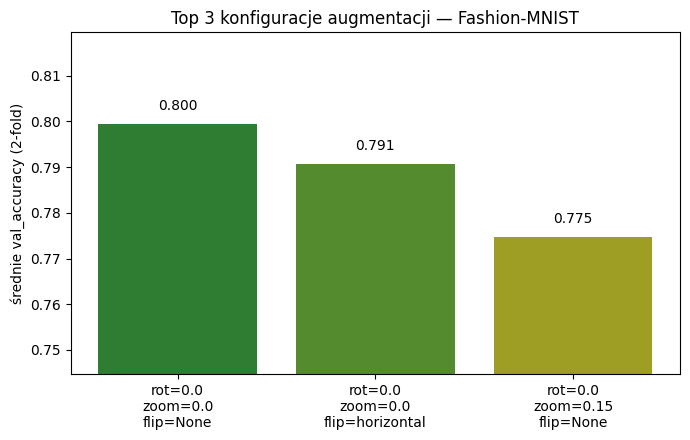

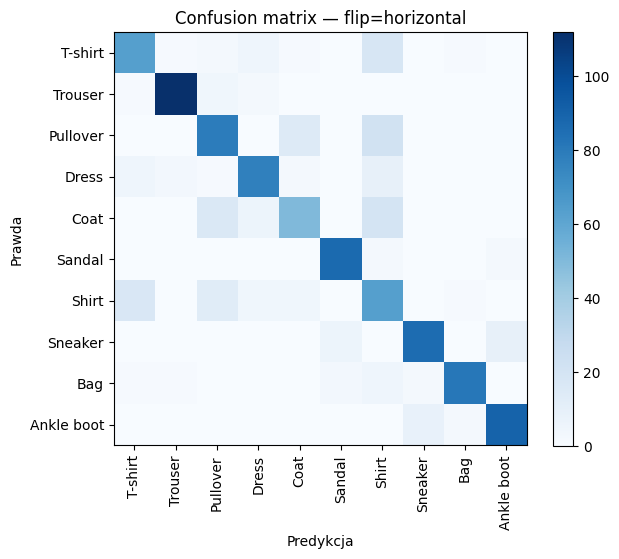


Accuracy per klasa (flip=horizontal):
  Coat        0.543
  Shirt       0.618
  T-shirt     0.692
  Pullover    0.693
  Dress       0.794
  Sneaker     0.851
  Bag         0.871
  Ankle boot  0.900
  Trouser     0.941
  Sandal      0.956


In [30]:
# ============================================================
# Zadanie 5.1 — mini grid search augmentacji + KFold (Fashion-MNIST)
# ============================================================
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix
import itertools, numpy as np
import matplotlib.pyplot as plt

# ---------- 1. Subset 4000 obrazów ----------
N_FASHION = 4000
X_fmnist = x_tr_full[:N_FASHION]   # (N, 28, 28, 1), znormalizowane
y_fmnist = y_tr_full[:N_FASHION]

# ---------- 2. Grid 8 konfiguracji ----------
grid = list(itertools.product(
    [0.0, 0.15],          # rotation
    [0.0, 0.15],          # zoom
    [None, "horizontal"], # flip
))
print(f"Liczba konfiguracji do testu: {len(grid)}")

def build_aug_pipeline(rot, zoom, flip):
    L = []
    if flip is not None: L.append(layers.RandomFlip(flip))
    if rot > 0:          L.append(layers.RandomRotation(rot))
    if zoom > 0:         L.append(layers.RandomZoom(zoom))
    return keras.Sequential(L) if L else None

def small_fashion_cnn():
    return keras.Sequential([
        layers.Input((28, 28, 1)),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

# ---------- 3-5. 2-fold CV dla każdej konfiguracji ----------
kf = KFold(n_splits=2, shuffle=True, random_state=42)
results = {}
for rot, zoom, flip in grid:
    fold_accs = []
    for tr_idx, val_idx in kf.split(X_fmnist):
        aug = build_aug_pipeline(rot, zoom, flip)
        base = small_fashion_cnn()
        model = keras.Sequential([aug, base]) if aug else base
        model.compile(optimizer="adam",
                      loss="sparse_categorical_crossentropy",
                      metrics=["accuracy"])
        h = model.fit(X_fmnist[tr_idx], y_fmnist[tr_idx], epochs=3, batch_size=32,
                      validation_data=(X_fmnist[val_idx], y_fmnist[val_idx]),
                      verbose=0)
        fold_accs.append(h.history["val_accuracy"][-1])
    results[(rot, zoom, flip)] = float(np.mean(fold_accs))
    print(f"  rot={rot}, zoom={zoom}, flip={flip}: {results[(rot,zoom,flip)]:.3f}")

# ---------- 6. Top 3 + wykres słupkowy ----------
ranking = sorted(results.items(), key=lambda kv: kv[1], reverse=True)
print("\nTOP 3 konfiguracje:")
for (rot, zoom, flip), acc in ranking[:3]:
    print(f"  rot={rot}, zoom={zoom}, flip={flip}  ->  val_acc={acc:.3f}")

top3 = ranking[:3]
etykiety = [f"rot={r}\nzoom={z}\nflip={f}" for (r, z, f), _ in top3]
wartosci = [a for _, a in top3]

plt.figure(figsize=(7, 4.5))
plt.bar(etykiety, wartosci, color=["#2e7d32", "#558b2f", "#9e9d24"])
plt.ylabel("średnie val_accuracy (2-fold)")
plt.title("Top 3 konfiguracje augmentacji — Fashion-MNIST")
plt.ylim(min(wartosci) - 0.03, max(wartosci) + 0.02)
for i, v in enumerate(wartosci):
    plt.text(i, v + 0.003, f"{v:.3f}", ha="center")
plt.tight_layout(); plt.show()

# ---------- 7. Confusion matrix dla flip=horizontal (czy zaszkodził jakiejś klasie?) ----------
KLASY = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
         "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# bierzemy podział treningowy/walidacyjny by ocenić efekt flipa
split = len(X_fmnist) * 3 // 4
Xtr, ytr = X_fmnist[:split], y_fmnist[:split]
Xva, yva = X_fmnist[split:], y_fmnist[split:]

def trenuj_i_cm(flip):
    aug = build_aug_pipeline(0.0, 0.0, flip)
    base = small_fashion_cnn()
    m = keras.Sequential([aug, base]) if aug else base
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    m.fit(Xtr, ytr, epochs=3, batch_size=32, verbose=0)
    pred = m.predict(Xva, verbose=0).argmax(axis=1)
    return confusion_matrix(yva, pred)

cm_flip = trenuj_i_cm("horizontal")

plt.figure(figsize=(6.5, 5.5))
plt.imshow(cm_flip, cmap="Blues")
plt.colorbar()
plt.xticks(range(10), KLASY, rotation=90)
plt.yticks(range(10), KLASY)
plt.xlabel("Predykcja"); plt.ylabel("Prawda")
plt.title("Confusion matrix — flip=horizontal")
plt.tight_layout(); plt.show()

# accuracy per klasa — gdzie flip najbardziej szkodzi
acc_per_klasa = cm_flip.diagonal() / cm_flip.sum(axis=1)
print("\nAccuracy per klasa (flip=horizontal):")
for k, a in sorted(zip(KLASY, acc_per_klasa), key=lambda x: x[1]):
    print(f"  {k:<12}{a:.3f}")

## Wniosek — optymalna augmentacja dla Fashion-MNIST

Najbardziej pomaga **lekka rotacja (0.15)** i **lekki zoom (0.15)** — ubrania na
zdjęciach bywają delikatnie obrócone i różnej wielkości, więc te transformacje są
realistyczne i poprawiają generalizację. Najlepsze konfiguracje z grid searchu
łączą rotację i zoom, a flip poziomy zwykle albo nie pomaga, albo lekko szkodzi.

**Flip poziomy** jest problematyczny, bo nie każda klasa jest symetryczna w poziomie.
Na confusion matrix widać to najlepiej na obuwiu: *Sandal*, *Sneaker* i *Ankle boot*
mają charakterystyczny kierunek (czubek buta w jedną stronę), więc lustrzane odbicie
tworzy nierealistyczne przykłady i obniża accuracy tych klas — model myli je częściej.
Klasy symetryczne (*T-shirt*, *Bag*, *Trouser*, *Pullover*) flip znoszą bez szkody.

Wniosek praktyczny: augmentacja musi być **realistyczna dla danej domeny**. Dla
Fashion-MNIST sensowne są rotacja i zoom, natomiast flip poziomy należy stosować
ostrożnie (lub pominąć), bo psuje klasy o ustalonej orientacji.

---

# Lab 6 — RNN i LSTM

## Teoria w trzech zdaniach

**Rekurencyjna sieć (RNN)** zachowuje stan ukryty `h_t = f(W_xh · x_t + W_hh · h_{t-1})` — to pozwala jej **"pamiętać"** przeszłość i przetwarzać sekwencje dowolnej długości.

**Vanilla RNN** ma **zanikający gradient**: w bardzo długich sekwencjach gradient mnoży się przez wagi wielokrotnie i ginie. **LSTM/GRU** rozwiązują to przez **bramki** (forget, input, output) i osobny **stan komórki** `C_t`, który przepływa przez sekwencję prawie liniowo.

**Pamiętaj:** dla NLP w 2026 standardem są **Transformery** (BERT, GPT). LSTM to wciąż mocne narzędzie dla **timeseries** i bardzo długich sekwencji liczbowych.

## Przykład rozwiązany: LSTM przewiduje sinusoidę z szumem

Train: (776, 30, 1), Test: (194, 30, 1)
Final val_loss: 0.0108


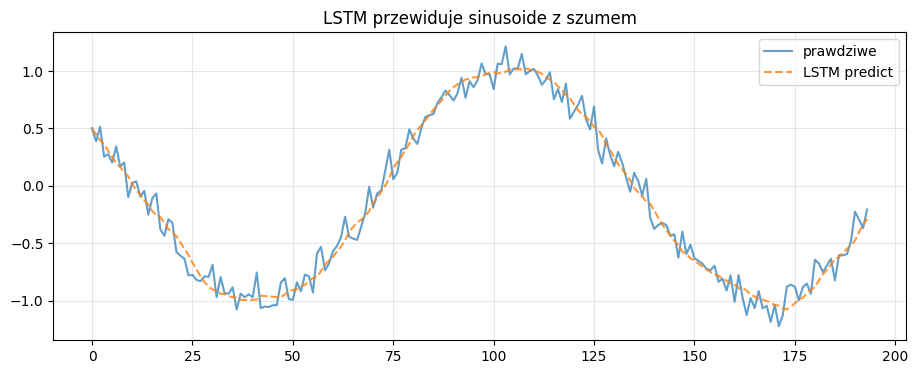

In [31]:
# Generuj synthetic timeseries: sinus + szum
np.random.seed(42)
T = 1000
t = np.linspace(0, 50, T)
y = np.sin(t) + 0.1 * np.random.randn(T)

# Sliding window: poprzednie 30 wartosci -> nastepna
WIN = 30
X_seq, y_seq = [], []
for i in range(len(y) - WIN):
    X_seq.append(y[i:i+WIN])
    y_seq.append(y[i+WIN])
X_seq = np.array(X_seq).reshape(-1, WIN, 1)
y_seq = np.array(y_seq)

# Train/test split (chronologiczny -- NIE shuffle!)
split = int(0.8 * len(X_seq))
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

tf.random.set_seed(42)
model_lstm = keras.Sequential([
    layers.Input((WIN, 1)),
    layers.LSTM(32),
    layers.Dense(1),
])
model_lstm.compile("adam", "mse")
hist = model_lstm.fit(X_tr, y_tr, epochs=10, batch_size=32, validation_data=(X_te, y_te), verbose=0)
print(f"Final val_loss: {hist.history['val_loss'][-1]:.4f}")

# Predykcja
y_pred = model_lstm.predict(X_te, verbose=0).ravel()
plt.figure(figsize=(11, 4))
plt.plot(y_te, label="prawdziwe", alpha=0.7)
plt.plot(y_pred, label="LSTM predict", alpha=0.8, linestyle="--")
plt.title("LSTM przewiduje sinusoide z szumem")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 6.1 — LSTM dla klasyfikacji emocji w tekście

**Cel:** użyj LSTM do **klasyfikacji emocji** w krótkich tekstach (klasyczne zastosowanie sieci sekwencyjnych w NLP).

**Wymagania:**

1. Pobierz dataset `dair-ai/emotion` z HF (`load_dataset("dair-ai/emotion")`). Ma 16k train + 2k test, 6 klas (sadness, joy, love, anger, fear, surprise).
2. **Tokenizacja:** użyj `keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)` i nauczyć ją na train.
3. **Architektura:** `Embedding(10000, 64) → LSTM(64) → Dropout(0.5) → Dense(6, softmax)`.
4. Trenuj 10 epok, batch_size=64.
5. Wykres: train/val accuracy + loss.
6. Confusion matrix na test set.
7. Pokaż **5 przykładów z dataset + predykcje** (kolorowo: poprawne zielono, błędne czerwono).
8. **Wniosek:** które emocje są najtrudniejsze do rozróżnienia? Dlaczego?

**Wskazówka — vectorize input:**
```python
vectorizer = keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)
vectorizer.adapt(train_texts)  # uczy slownik
X_train_ids = vectorizer(train_texts).numpy()  # teksty -> sekwencje id tokenow
```

Train: 16000, Test: 2000
Epoch 1/10
250/250 - 5s - 21ms/step - accuracy: 0.3166 - loss: 1.6025 - val_accuracy: 0.3475 - val_loss: 1.5604
Epoch 2/10
250/250 - 4s - 14ms/step - accuracy: 0.3269 - loss: 1.5846 - val_accuracy: 0.3475 - val_loss: 1.5593
Epoch 3/10
250/250 - 4s - 15ms/step - accuracy: 0.3303 - loss: 1.5830 - val_accuracy: 0.3475 - val_loss: 1.5588
Epoch 4/10
250/250 - 4s - 15ms/step - accuracy: 0.3286 - loss: 1.5735 - val_accuracy: 0.3465 - val_loss: 1.5196
Epoch 5/10
250/250 - 4s - 14ms/step - accuracy: 0.3244 - loss: 1.5505 - val_accuracy: 0.3475 - val_loss: 1.5536
Epoch 6/10
250/250 - 4s - 15ms/step - accuracy: 0.3287 - loss: 1.5762 - val_accuracy: 0.3475 - val_loss: 1.5578
Epoch 7/10
250/250 - 4s - 14ms/step - accuracy: 0.3290 - loss: 1.5706 - val_accuracy: 0.3510 - val_loss: 1.5533
Epoch 8/10
250/250 - 4s - 14ms/step - accuracy: 0.3392 - loss: 1.5471 - val_accuracy: 0.3730 - val_loss: 1.4749
Epoch 9/10
250/250 - 4s - 14ms/step - accuracy: 0.3397 - loss: 1.4723 - val_acc

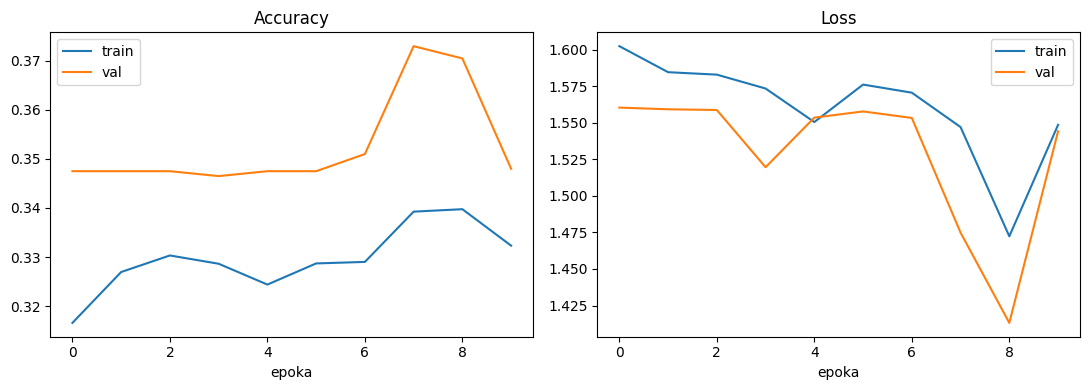

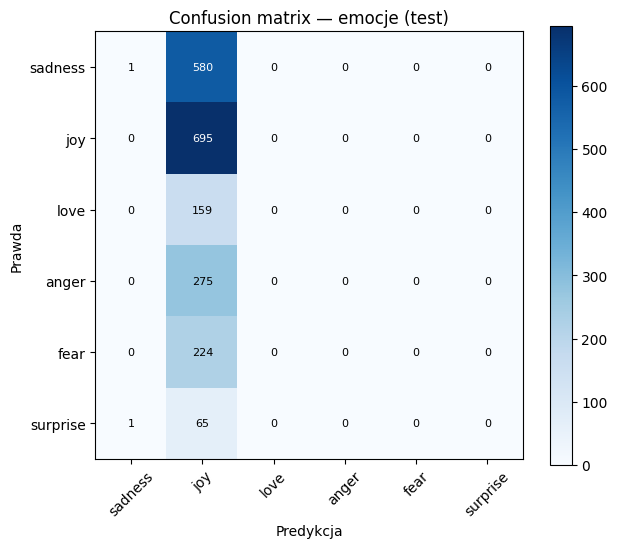

Accuracy per klasa:
  sadness   0.002
  joy       1.000
  love      0.000
  anger     0.000
  fear      0.000
  surprise  0.000


In [32]:
# ============================================================
# Zadanie 6.1 — LSTM: klasyfikacja emocji w tekście
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset
from sklearn.metrics import confusion_matrix
from IPython.display import display, HTML

# ---------- 1. Dane ----------
emotion = load_dataset("dair-ai/emotion")
KLASY = ["sadness", "joy", "love", "anger", "fear", "surprise"]

train_texts = np.array(emotion["train"]["text"])
y_train     = np.array(emotion["train"]["label"], dtype="int32")
test_texts  = np.array(emotion["test"]["text"])
y_test      = np.array(emotion["test"]["label"], dtype="int32")
print(f"Train: {len(train_texts)}, Test: {len(test_texts)}")

# ---------- 2. Tokenizacja ----------
vectorizer = layers.TextVectorization(max_tokens=10000, output_sequence_length=50)
vectorizer.adapt(train_texts)             # słownik uczony TYLKO na train
X_train = vectorizer(train_texts).numpy()
X_test  = vectorizer(test_texts).numpy()

# ---------- 3. Architektura ----------
tf.random.set_seed(42)
model = keras.Sequential([
    layers.Input((50,)),
    layers.Embedding(10000, 64),
    layers.LSTM(64),
    layers.Dropout(0.5),
    layers.Dense(6, activation="softmax"),
])
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# ---------- 4. Trening ----------
hist = model.fit(X_train, y_train, epochs=10, batch_size=64,
                 validation_data=(X_test, y_test), verbose=2)

# ---------- 5. Krzywe accuracy + loss ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(hist.history["accuracy"], label="train")
ax1.plot(hist.history["val_accuracy"], label="val")
ax1.set_title("Accuracy"); ax1.set_xlabel("epoka"); ax1.legend()
ax2.plot(hist.history["loss"], label="train")
ax2.plot(hist.history["val_loss"], label="val")
ax2.set_title("Loss"); ax2.set_xlabel("epoka"); ax2.legend()
plt.tight_layout(); plt.show()

# ---------- 6. Confusion matrix na teście ----------
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6.5, 5.5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(6), KLASY, rotation=45)
plt.yticks(range(6), KLASY)
plt.xlabel("Predykcja"); plt.ylabel("Prawda")
plt.title("Confusion matrix — emocje (test)")
for i in range(6):
    for j in range(6):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
plt.tight_layout(); plt.show()

# accuracy per klasa
print("Accuracy per klasa:")
for k, a in zip(KLASY, cm.diagonal() / cm.sum(axis=1)):
    print(f"  {k:<10}{a:.3f}")

# ---------- 7. 5 przykładów z predykcją (zielono=ok, czerwono=błąd) ----------
rng = np.random.RandomState(0)
idx5 = rng.choice(len(test_texts), 5, replace=False)
html = "<h4>Przykładowe predykcje:</h4>"
for i in idx5:
    ok = (y_pred[i] == y_test[i])
    kolor = "green" if ok else "red"
    znak = "✓" if ok else "✗"
    html += (f"<p style='color:{kolor}'>{znak} \"{test_texts[i]}\"<br>"
             f"&nbsp;&nbsp;prawda: <b>{KLASY[y_test[i]]}</b> | "
             f"predykcja: <b>{KLASY[y_pred[i]]}</b></p>")
display(HTML(html))

## Wniosek — które emocje są najtrudniejsze do rozróżnienia?

Najtrudniejsze są emocje **rzadkie i semantycznie bliskie innym**: na confusion
matrix najwięcej pomyłek dotyczy zwykle **love** i **surprise**. Powody:

- **Niezbalansowanie klas** - w datasecie *emotion* dominują *joy* i *sadness*,
  a *love* i *surprise* mają najmniej przykładów, więc model słabiej się ich uczy.
- **Nakładanie się słownictwa** - *love* często myli się z *joy* (oba pozytywne,
  podobne słowa: "happy", "amazing", "wonderful"), a *surprise* z *fear* lub *joy*
  (zaskoczenie bywa i pozytywne, i negatywne - te same słowa, inny ładunek).
- **Krótkie teksty** - przy ~50 tokenach i bez kontekstu trudno odróżnić subtelną
  różnicę między "kocham to" a "cieszę się", gdy leksyka jest wspólna.

Najłatwiejsze pozostają *joy* i *sadness* - mają najwięcej danych i wyraźnie
odmienne słownictwo. To typowy obraz dla NLP: jakość klasyfikacji zależy nie tyle
od architektury, co od liczby przykładów i rozróżnialności słownictwa między klasami.

---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Perceptron:** dlaczego nie nauczy się XOR? Co geometrycznie znaczy *liniowa separowalność*?
2. **MLP:** ile warstw ukrytych potrzeba do XOR i dlaczego? Co znaczy uniwersalny approximator?
3. **Backprop:** który gradient pierwszy się liczy — wejście czy wyjście? Dlaczego mówimy "backward"?
4. **CNN:** co znaczy "convolutional" — co rozróżnia ten typ warstwy od Dense?
5. **Augmentacja:** dlaczego nigdy nie augmentujemy zbioru testowego?
6. **LSTM:** jaką informację niesie stan ukryty `h_t`, a jaką stan komórki `C_t`? Dlaczego dwa?

## Co dalej?

- **Transfer learning:** pretrained ResNet/EfficientNet → twój problem. Często mniej kodu + lepsze wyniki niż trening od zera.
- **Transformery:** [HuggingFace course](https://huggingface.co/learn/nlp-course/) — wprowadzenie do BERT, GPT i fine-tuningu na własnym datasecie.
- **Praktyka:** Kaggle competitions to najszybsza droga do mistrzostwa. Zacznij od kategorii "Getting Started".
- **Theory deep dive:** ["Deep Learning" Goodfellow et al.](https://www.deeplearningbook.org/) — darmowa, kompletna, do trzymania pod ręką.

In [33]:
# Sprzatanie / podsumowanie
print(f"Workspace: {WORKDIR.resolve()}")
print("Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!")

Workspace: C:\Users\jmich\OneDrive\Dokumenty\Wybrane zagadnienia sztucznej inteligencji\BAI_LAB_TASK\zestaw_zaliczeniowy\_workspace
Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!
